In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns

In [4]:
# Load CSV file into a dataframe
df = pd.read_csv(r"C:\Users\tmanuel\OneDrive - Cox Communications\Documents\Coursework\im310_v4_wk2_auto_accident_dataset.analysis.csv")

In [5]:
# Overview of data

df.describe()

,CASENUM,STRATUM,REGION,URBANICITY,NUM_INJ,MONTH,YEAR,DAY_WEEK,HOUR,MINUTE,HARM_EV,ALCOHOL,LGT_COND,INT_HWY,WEATHER,WKDY_IM,LGTCON_IM,
count,1.439000e+03,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.0,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,0.0
mean,2.020022e+11,7.544823,2.845726,1.303683,2.833912,1.004864,2020.0,4.241140,13.346769,28.262682,16.080612,4.218902,1.879083,0.123002,7.572620,4.241140,1.806810,NaN
std,2.187705e+04,2.442789,0.584781,0.460007,14.305365,0.184530,0.0,1.879049,7.059944,17.326102,11.083344,3.321030,1.297521,0.328554,20.887808,1.879049,1.108286,NaN
min,2.020021e+11,2.000000,1.000000,1.000000,0.000000,1.000000,2020.0,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,NaN
25%,2.020021e+11,6.000000,3.000000,1.000000,0.000000,1.000000,2020.0,3.000000,9.000000,15.000000,12.000000,2.000000,1.000000,0.000000,1.000000,3.000000,1.000000,NaN
50%,2.020022e+11,8.000000,3.000000,1.000000,0.000000,1.000000,2020.0,4.000000,14.000000,29.000000,12.000000,2.000000,1.000000,0.000000,1.000000,4.000000,1.000000,NaN
75%,2.020022e+11,10.000000,3.000000,2.000000,1.000000,1.000000,2020.0,6.000000,17.000000,43.000000,12.000000,9.000000,3.000000,0.000000,4.000000,6.000000,3.000000,NaN
max,2.020022e+11,10.000000,4.000000,2.000000,99.000000,8.000000,2020.0,7.000000,99.000000,99.000000,93.000000,9.000000,9.000000,1.000000,99.000000,7.000000,6.000000,NaN


In [6]:
# Investigate correlation of alcohol and number of injuries
df.groupby('ALCOHOL')['NUM_INJ'].describe()

alcohol_df = df[df['ALCOHOL'].isin([1,2])]
alcohol_df.groupby(['ALCOHOL','URBANICITY'])['NUM_INJ'].describe()

count      mean        std  min  25%  50%   75%   max
ALCOHOL URBANICITY                                                       
1       1            49.0  1.346939   1.267396  0.0  0.0  1.0  2.00   6.0
        2            26.0  4.807692  19.235424  0.0  0.0  1.0  1.75  99.0
2       1           682.0  0.913490   3.924376  0.0  0.0  0.0  1.00  99.0
        2           215.0  0.469767   0.702311  0.0  0.0  0.0  1.00   4.0

In [7]:
# Look for outliers
alcohol_df[(alcohol_df['ALCOHOL'] == 1) & (alcohol_df['URBANICITY'] == 2)]['NUM_INJ'].sort_values(ascending=False).head(10)

1047    99
72       3
1129     3
161      3
775      2
839      2
1383     2
160      1
413      1
340      1
Name: NUM_INJ, dtype: int64

In [8]:
# Discovered that "99 injuries" is actually code for "unknown". Re-code "99 injuries" to "unknown"
df['NUM_INJ'] = df['NUM_INJ'].replace(99, pd.NA)
df['NUM_INJ'] = pd.to_numeric(df['NUM_INJ'], errors='coerce')

alcohol_df = df[df['ALCOHOL'].isin([1,2])]


In [9]:
# Re-examine data
alcohol_df.groupby(['ALCOHOL','URBANICITY'])['NUM_INJ'].describe()

count      mean       std  min  25%  50%  75%  max
ALCOHOL URBANICITY                                                    
1       1            49.0  1.346939  1.267396  0.0  0.0  1.0  2.0  6.0
        2            25.0  1.040000  0.978093  0.0  0.0  1.0  1.0  3.0
2       1           681.0  0.769457  1.119877  0.0  0.0  0.0  1.0  8.0
        2           215.0  0.469767  0.702311  0.0  0.0  0.0  1.0  4.0

In [10]:
# Create a summary table
injury_summary = (alcohol_df.groupby(['ALCOHOL','URBANICITY'])['NUM_INJ'].mean().reset_index())

injury_summary['ALCOHOL'] = injury_summary['ALCOHOL'].map({
    1: 'Alcohol Involved',
    2: 'No Alcohol'
})

injury_summary['URBANICITY'] = injury_summary['URBANICITY'].map({
    1: 'Urban',
    2: 'Rural'
})

print(injury_summary)

            ALCOHOL URBANICITY   NUM_INJ
0  Alcohol Involved      Urban  1.346939
1  Alcohol Involved      Rural  1.040000
2        No Alcohol      Urban  0.769457
3        No Alcohol      Rural  0.469767


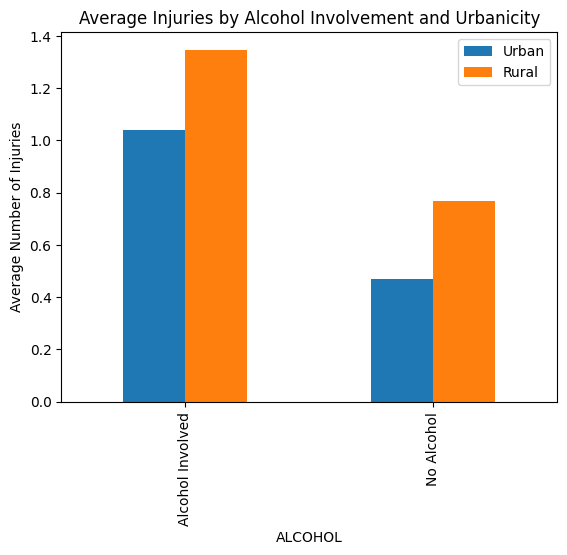

In [11]:
# Grouped bar chart
pivot = injury_summary.pivot(
    index = 'ALCOHOL',
    columns = 'URBANICITY',
    values = 'NUM_INJ'
)
pivot.plot(kind='bar')

plt.title('Average Injuries by Alcohol Involvement and Urbanicity')
plt.ylabel('Average Number of Injuries')
plt.legend(['Urban', 'Rural'])
plt.show()

<Axes: xlabel='ALCOHOL', ylabel='NUM_INJ'>

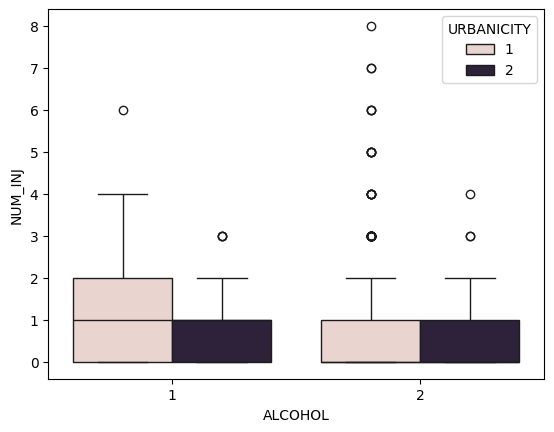

In [12]:
# Create a boxplot
sns.boxplot(x = 'ALCOHOL',
            y = 'NUM_INJ',
            hue = 'URBANICITY',
            data = alcohol_df
            )

In [13]:
# Investigate injury by region
df.groupby('REGION')['NUM_INJ'].describe()

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
1,22.0,0.500000,0.963624,0.0,0.0,0.0,1.0,4.0
2,296.0,0.594595,0.842417,0.0,0.0,0.0,1.0,4.0
3,962.0,0.861746,3.307453,0.0,0.0,0.0,1.0,98.0
4,129.0,0.713178,1.160508,0.0,0.0,0.0,1.0,7.0


In [14]:
# Discovered that "98 injuries" is code for "No persons involved". Change "98 injuries" to "NAN"
df['NUM_INJ'] = df['NUM_INJ'].replace(98, pd.NA)
df['NUM_INJ'] = pd.to_numeric(df['NUM_INJ'], errors='coerce')

In [15]:
# Re-investigate injuries by region
df.groupby('REGION')['NUM_INJ'].describe()

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
1,22.0,0.500000,0.963624,0.0,0.0,0.0,1.0,4.0
2,296.0,0.594595,0.842417,0.0,0.0,0.0,1.0,4.0
3,961.0,0.760666,1.054234,0.0,0.0,0.0,1.0,8.0
4,129.0,0.713178,1.160508,0.0,0.0,0.0,1.0,7.0


In [19]:
# Create region map
region_map = {
    'PA': 1, 'NJ': 1, 'NY': 1, 'NH': 1, 'VT': 1, 'RI': 1, 'MA': 1, 'ME': 1, 'CT': 1,
    'OH': 2, 'IN': 2, 'IL': 2, 'MI': 2, 'WI': 2, 'MN': 2, 'ND': 2, 'SD': 2, 'NE': 2, 'IA': 2, 'MO': 2, 'KS': 2,
    'MD': 3, 'DE': 3, 'DC': 3, 'WV': 3, 'VA': 3, 'KY': 3, 'TN': 3, 'NC': 3, 'SC': 3, 'GA': 3, 'FL': 3, 'AL': 3, 'MS': 3, 'LA': 3, 'AR': 3, 'OK': 3, 'TX': 3,
    'MT': 4, 'ID': 4, 'WA': 4, 'OR': 4, 'CA': 4, 'NV': 4, 'NM': 4, 'AZ': 4, 'UT': 4, 'CO': 4, 'WY': 4, 'AK': 4, 'HI': 4
}

state_df = pd.DataFrame(list(region_map.items()),columns = ['State', 'Region'])
print(state_df.head())

  State  Region
0    PA       1
1    NJ       1
2    NY       1
3    NH       1
4    VT       1
